<a href="https://colab.research.google.com/github/tcsweetser/ipv4_prices/blob/main/ipv4_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data loaded and cleaned successfully!
Analyzing 5511 sales records from 2014-02-06 to 2026-06-19.
             Analysis of IPv4 Price Trends

📈 Peak Market Price (The Inflection Point):
The market peaked in February 2022, reaching an average of $52.19 per address.
This marks the turning point before the sustained price decline began.

📉 Five Months with the Steepest Price Drops:
These periods represent the fastest devaluation of IPv4 addresses.
  - March 2014: Price dropped by 54.03%
  - April 2015: Price dropped by 12.48%
  - March 2026: Price dropped by 11.43%
  - November 2015: Price dropped by 11.31%
  - November 2014: Price dropped by 11.23%



/tmp/ipykernel_19306/578853255.py:69: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(peak_date, peak_price, 'o', color='red', markersize=10, label=f"Peak: ${peak_price:.2f}\n({peak_date.strftime('%b %Y')})")


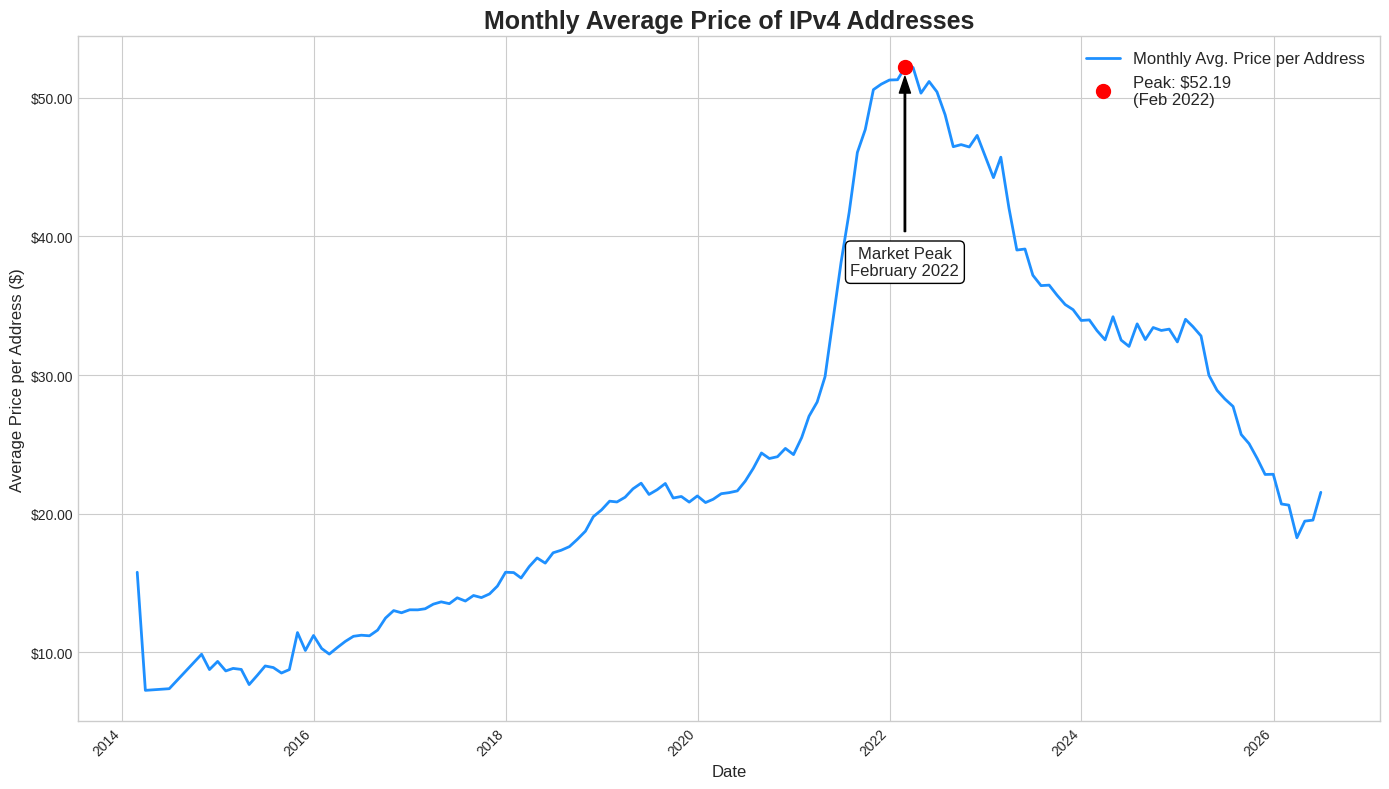

Analyzing 3032 sales records after the peak date of 2022-02-28...
     Projected Dates for IPv4 Prices to Reach $0
         (Based on Linear Trend After Peak)


,Slope (Price Change per Day),Projected Zero Date
Subnet Size,,
/16,-0.032789,2027-03-02
/17,-0.027092,2027-07-30
/18,-0.024525,2027-12-16
/19,-0.023685,2028-02-29
/20,-0.021483,2028-07-27
/21,-0.020248,2028-11-14
/22,-0.017519,2029-07-18
/23,-0.017842,2029-08-31
/24,-0.015105,2030-11-07


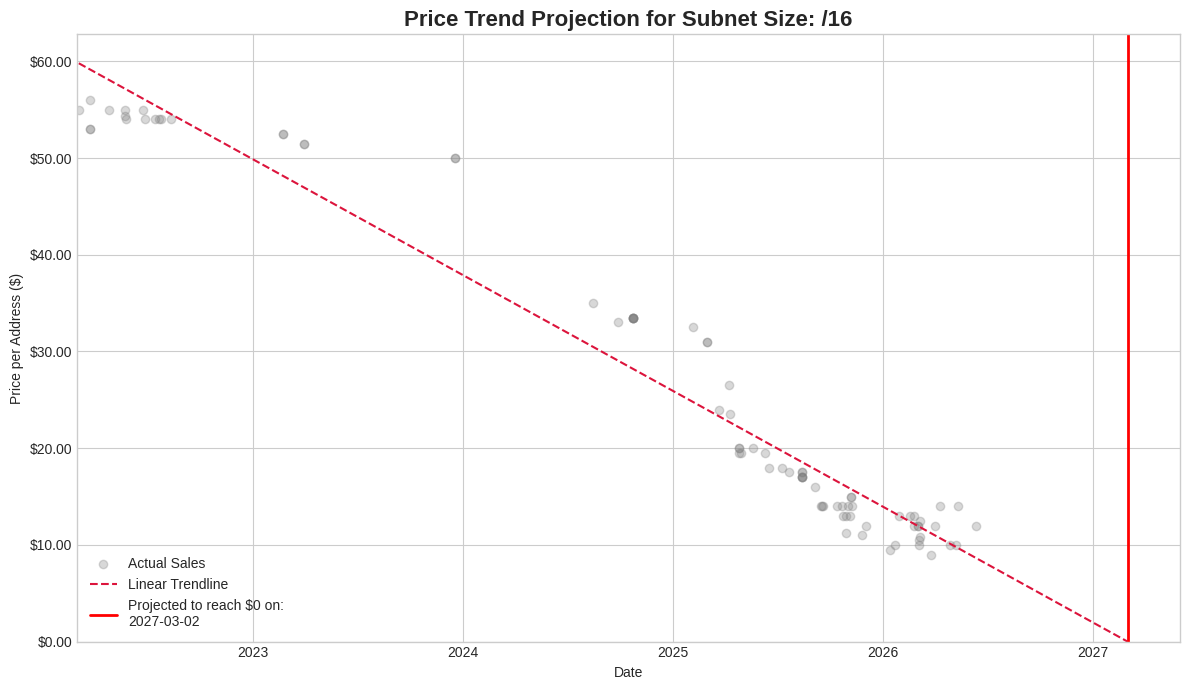

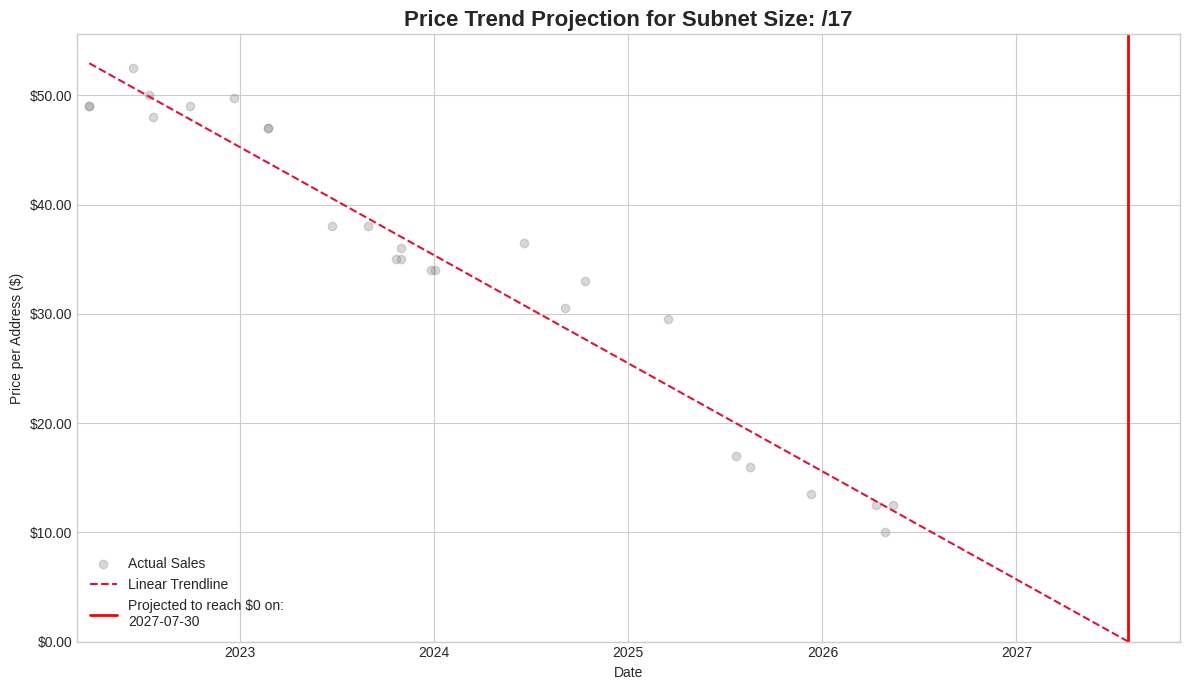

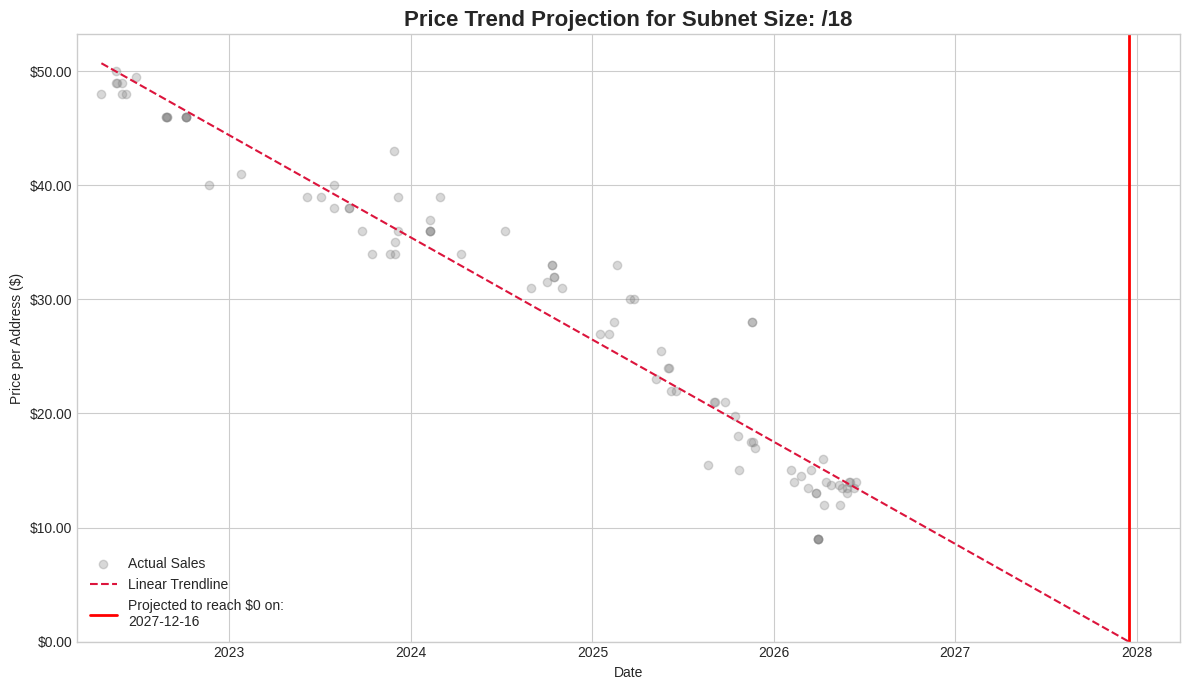

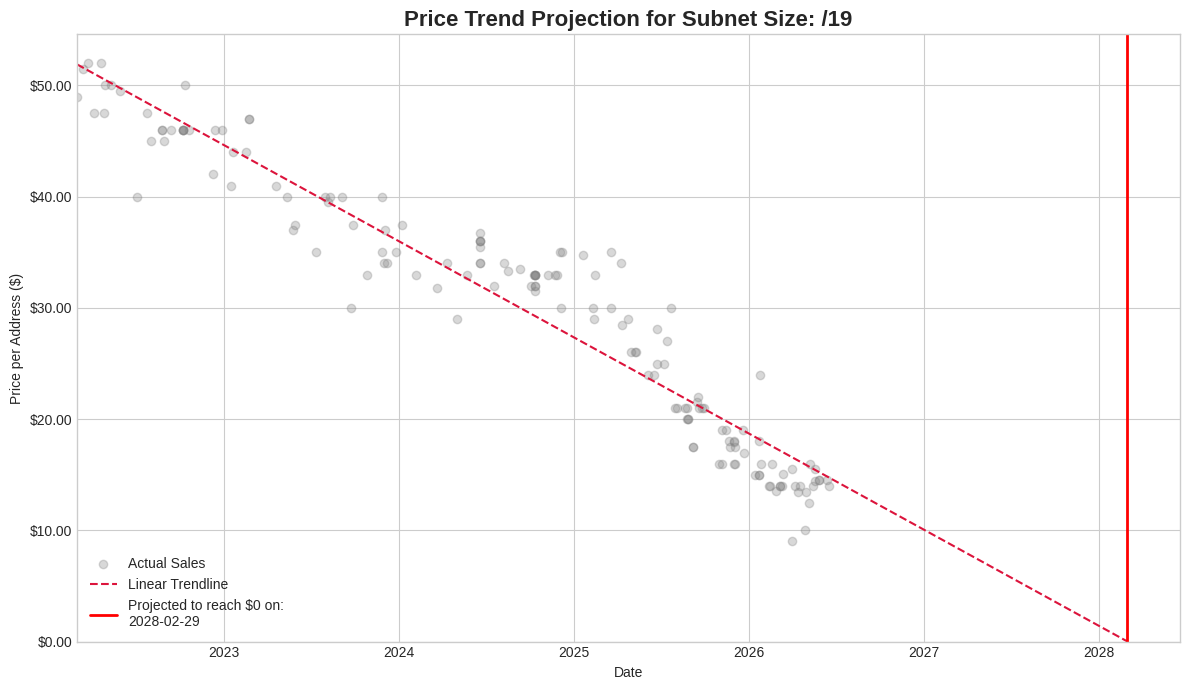

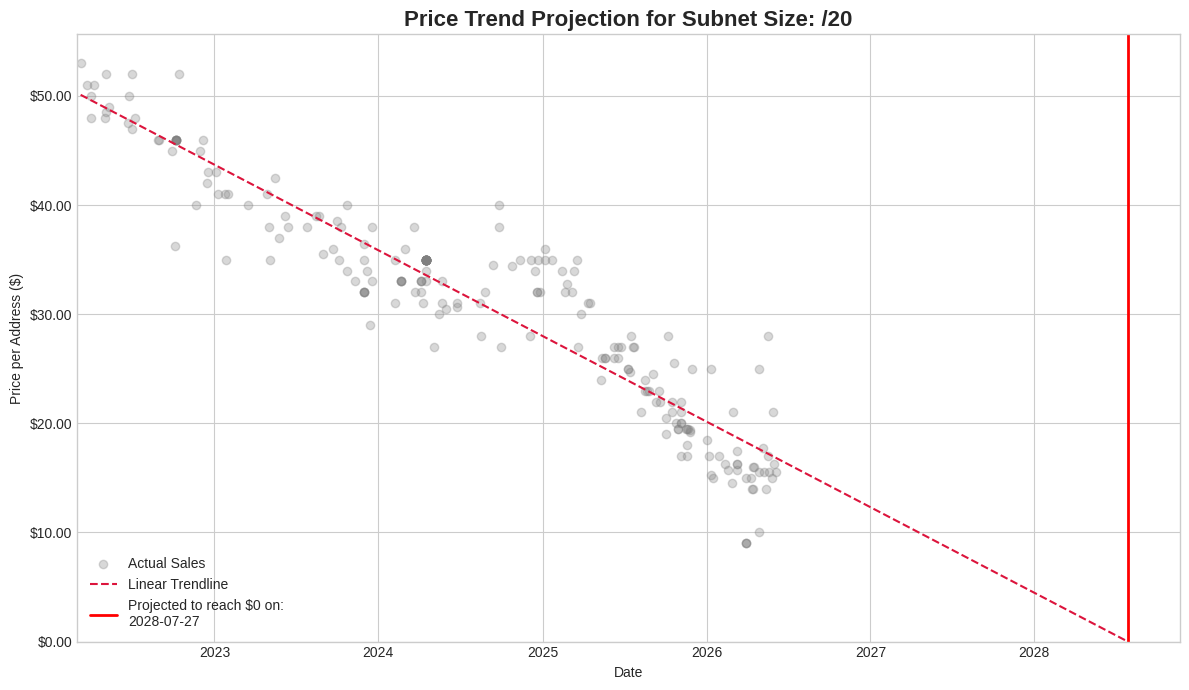

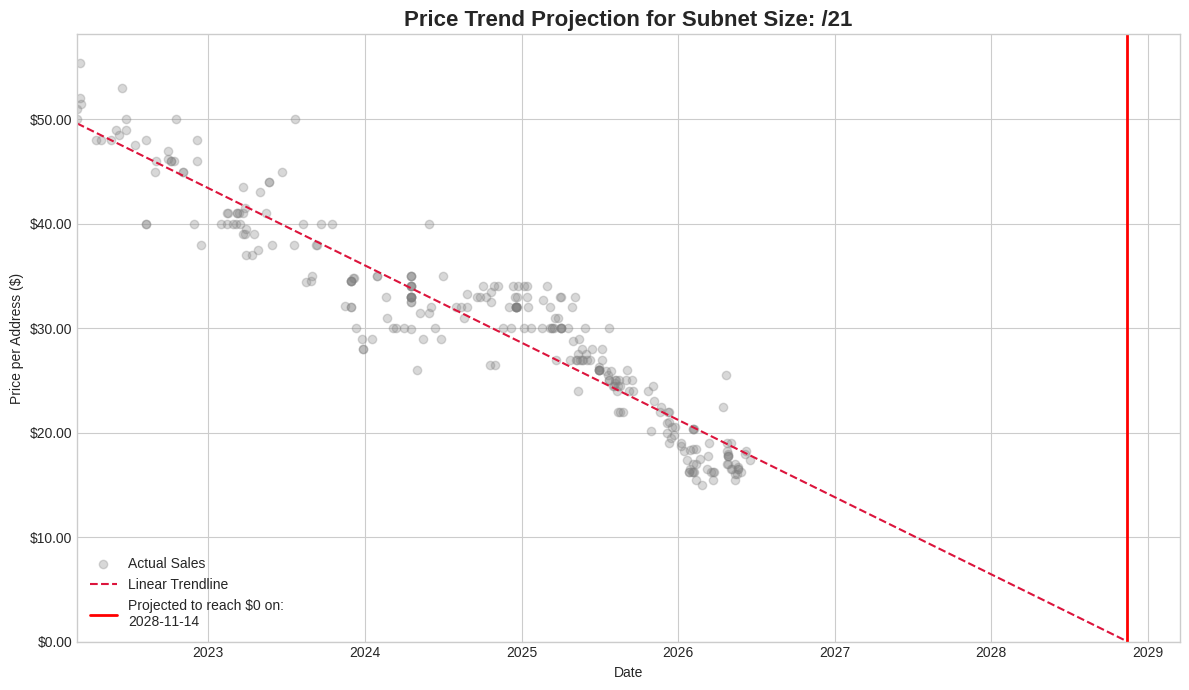

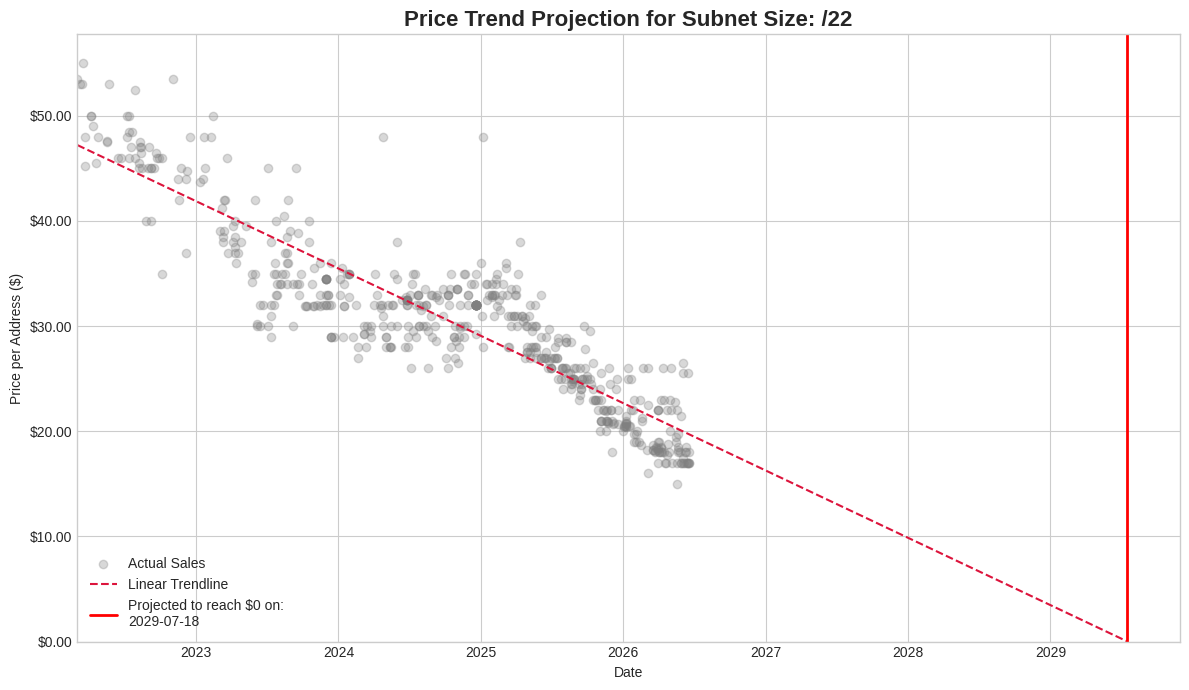

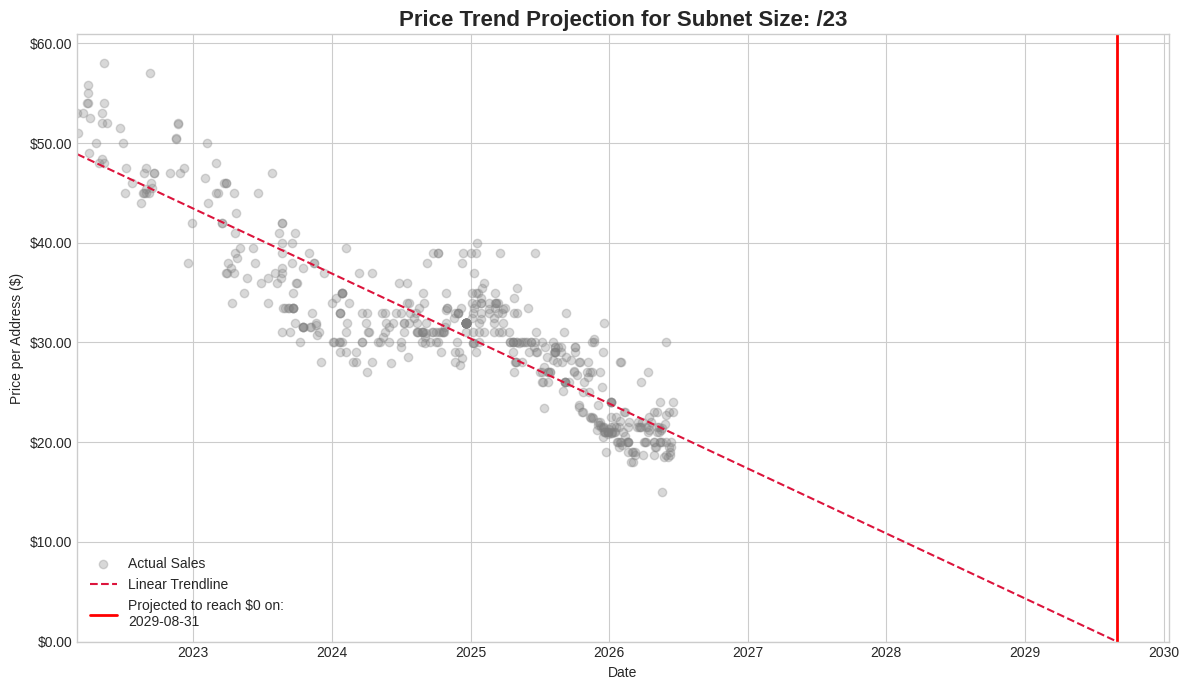

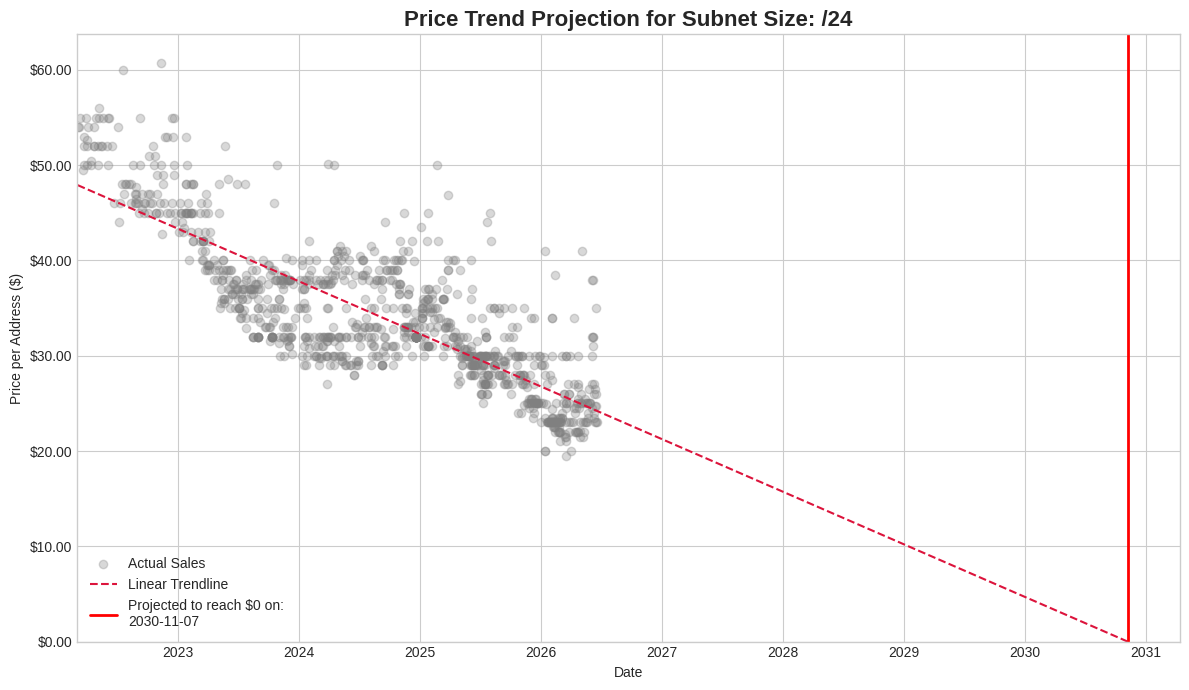

/tmp/ipykernel_19306/578853255.py:200: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', num_lines)


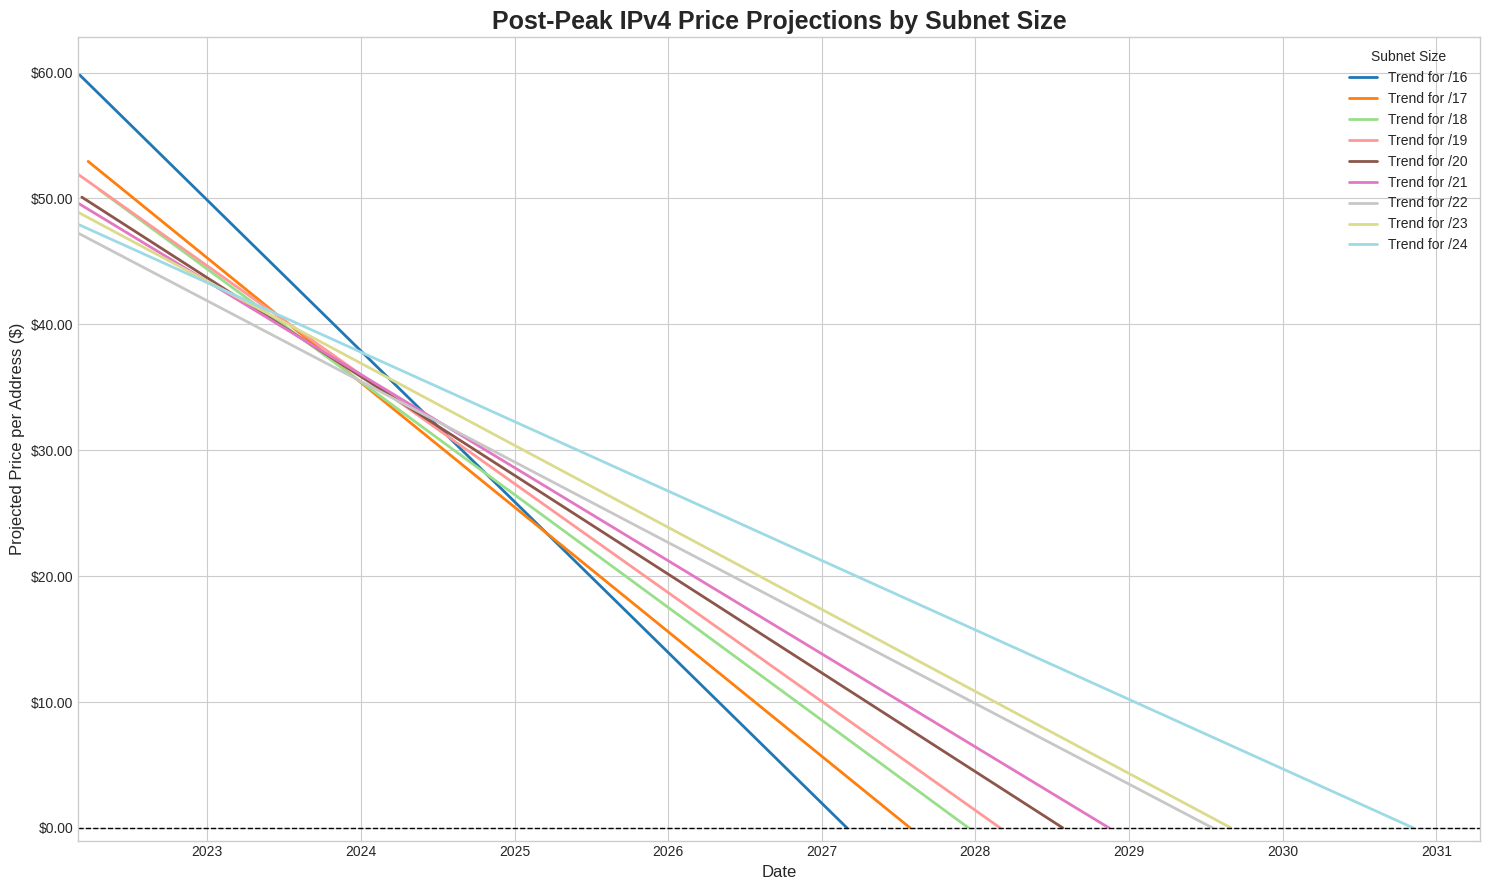

     Running Higher-Degree (3rd) Polynomial Projection

Analysis Complete. Displaying results.
   Projected Dates for IPv4 Prices to Reach $0
   (Based on 3rd-Degree Polynomial Trend After Peak)


,Projected Zero Date
Subnet Size,
/16,Trend does not reach zero in the future
/17,2027-03-26
/18,2026-12-31
/19,2026-12-03
/20,2026-12-18
/21,2027-02-06
/22,2027-03-12
/23,2027-03-31
/24,2027-07-29


/tmp/ipykernel_19306/578853255.py:324: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', num_lines)


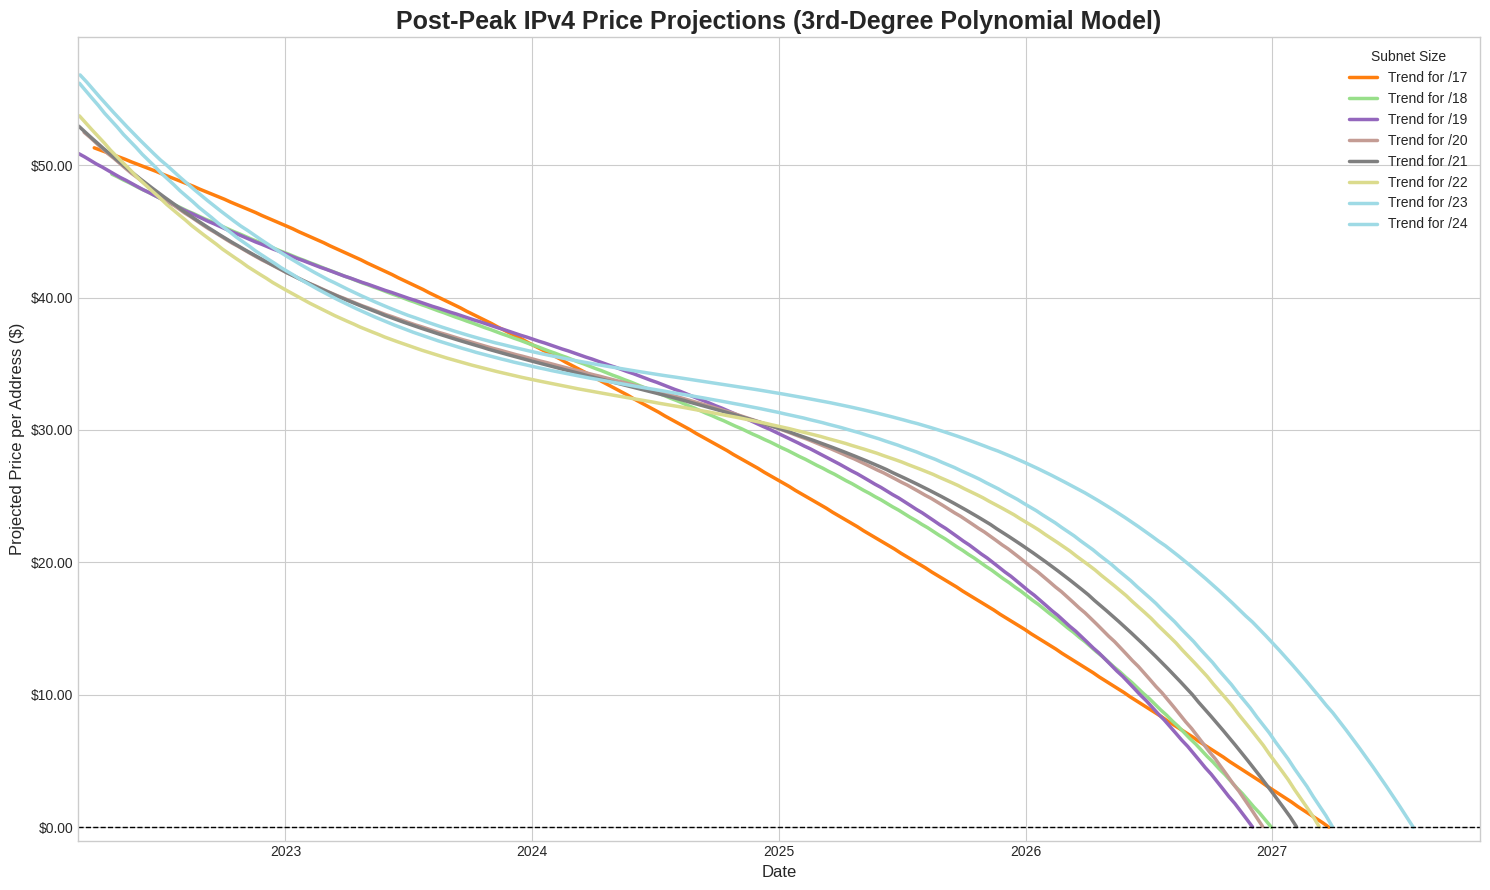

     Running Exponential Decay Projection Analysis (to $1.00)

Analysis Complete. Displaying results.
   Projected Dates for IPv4 Prices to Fall Below $1.00
        (Based on Exponential Decay Model)


,Projected $1.00 Date
Subnet Size,
/16,2032-04-25
/17,2033-08-25
/18,2034-05-11
/19,2035-06-22
/20,2036-12-08
/21,2038-06-03
/22,2040-12-09
/23,2041-10-15
/24,2046-09-30


/tmp/ipykernel_19306/578853255.py:430: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', num_lines)


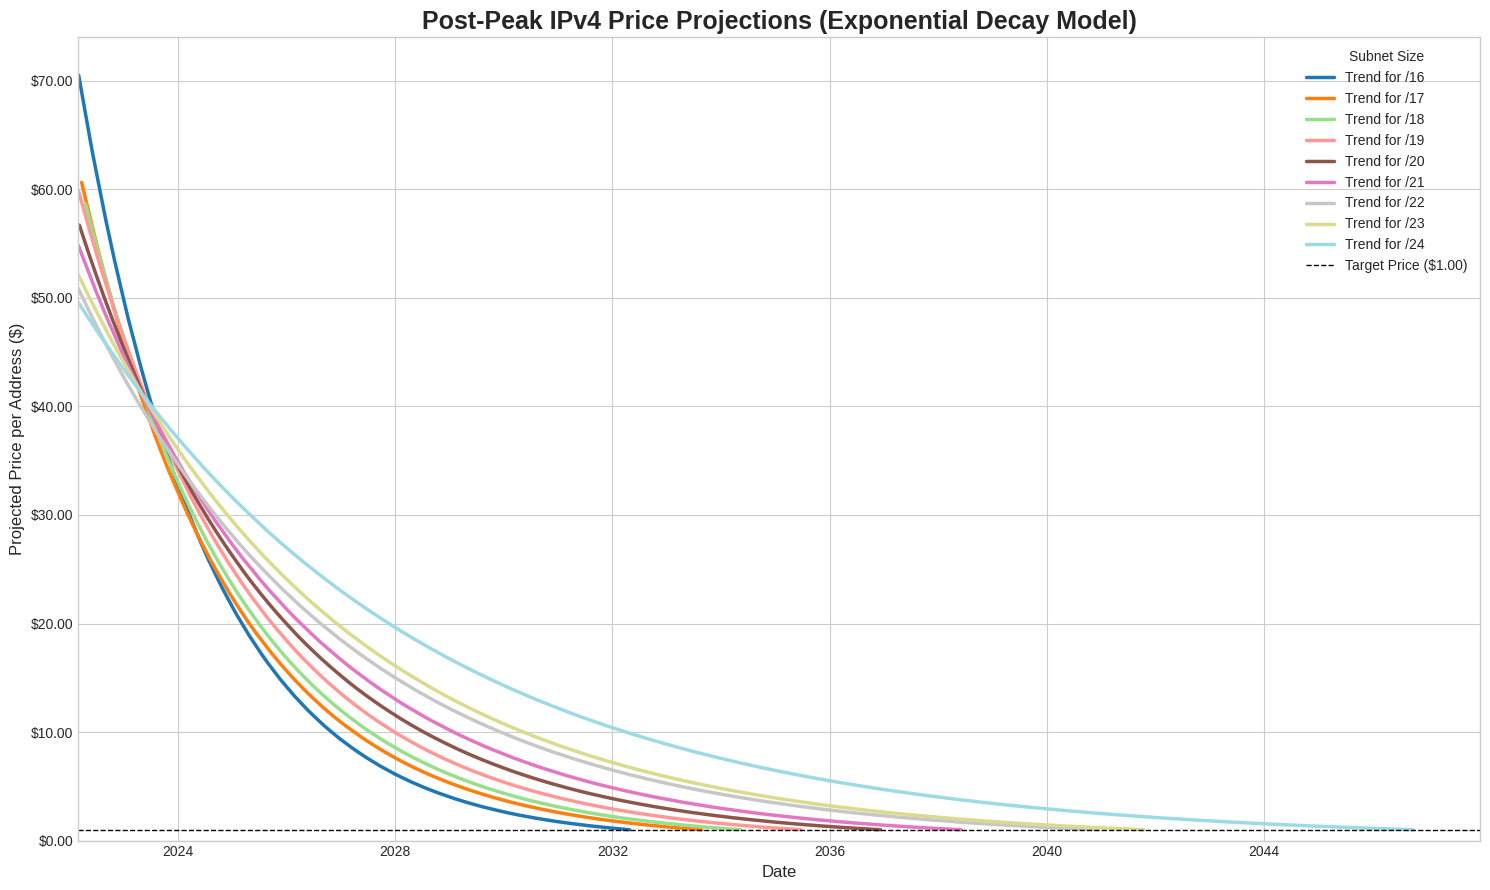

     Running Monte Carlo Simulation for Price Projections


Simulating Subnets:   0%|          | 0/11 [00:00<?, ?it/s]


Simulation Complete. Generating visualizations.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from google.colab import files
from sklearn.linear_model import LinearRegression
import numpy as np
from tqdm.notebook import tqdm

# Check to make sure the file was uploaded
file_name = "prior_sales.csv"

# Load the uploaded data into a pandas DataFrame
df = pd.read_csv(file_name)

# --- Data Cleaning ---
# Clean column names
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={'$/address': 'price_per_address'}, inplace=True)

# Convert data types
df['date'] = pd.to_datetime(df['date'])
df['price_per_address'] = df['price_per_address'].str.replace('$', '', regex=False).astype(float)

# Set date as the index and sort
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

print("Data loaded and cleaned successfully!")
print(f"Analyzing {len(df)} sales records from {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}.")

# --- Trend Analysis ---
# Resample by month and calculate the mean price.
monthly_avg_price = df['price_per_address'].resample('ME').mean().dropna()

# --- Find the Inflection Point (Peak Price) ---
peak_date = monthly_avg_price.idxmax()
peak_price = monthly_avg_price.max()

# --- Find Periods of Steepest Decline ---
monthly_pct_change = monthly_avg_price.pct_change()
steepest_drops = monthly_pct_change.nsmallest(5) # Find the 5 worst months

#### **Step 5: Display Analysis Results**

# --- Display the Analysis ---
print("="*60)
print("             Analysis of IPv4 Price Trends")
print("="*60)

print(f"\n📈 Peak Market Price (The Inflection Point):")
print(f"The market peaked in {peak_date.strftime('%B %Y')}, reaching an average of ${peak_price:.2f} per address.")
print("This marks the turning point before the sustained price decline began.")

print("\n📉 Five Months with the Steepest Price Drops:")
print("These periods represent the fastest devaluation of IPv4 addresses.")
for date, change in steepest_drops.items():
    print(f"  - {date.strftime('%B %Y')}: Price dropped by {abs(change):.2%}")

print("\n" + "="*60)

# --- Create the Visualization ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))

# Plot the monthly average price
monthly_avg_price.plot(ax=ax, label='Monthly Avg. Price per Address', color='dodgerblue', linewidth=2)

# --- Highlight the Peak ---
ax.plot(peak_date, peak_price, 'o', color='red', markersize=10, label=f"Peak: ${peak_price:.2f}\n({peak_date.strftime('%b %Y')})")
ax.annotate(
    f"Market Peak\n{peak_date.strftime('%B %Y')}",
    xy=(peak_date, peak_price),
    xytext=(peak_date, peak_price - 15),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
    ha='center',
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)
)

# --- Formatting the Plot ---
ax.set_title('Monthly Average Price of IPv4 Addresses', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Average Price per Address ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%1.2f'))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

# --- Filter Data to Post-Peak Period ---
df_after_peak = df[df.index > peak_date].copy()
print(f"Analyzing {len(df_after_peak)} sales records after the peak date of {peak_date.strftime('%Y-%m-%d')}...")

# Group by block size
grouped_data = df_after_peak.groupby('block')

projections = {}

# --- Iterate Through Each Subnet Size ---
for block_size, group_df in grouped_data:
    # We need enough data points to create a meaningful trendline
    if len(group_df) < 20:
        continue

    # --- Prepare Data for Linear Regression ---
    # X: Time (as number of days since the peak)
    # y: Price
    X = (group_df.index - peak_date).days.values.reshape(-1, 1)
    y = group_df['price_per_address'].values

    # --- Fit the Model ---
    model = LinearRegression()
    model.fit(X, y)

    slope = model.coef_[0]
    intercept = model.intercept_

    # We only care about assets with a negative price trend
    if slope >= 0:
        projections[block_size] = {
            'Slope (Price Change per Day)': slope,
            'Projected Zero Date': 'Price is not decreasing'
        }
        continue

    # --- Calculate the Date for $0 Price ---
    # Equation: 0 = slope * days + intercept
    # days = -intercept / slope
    days_to_zero = -intercept / slope
    zero_date = peak_date + pd.to_timedelta(days_to_zero, unit='D')

    projections[block_size] = {
        'Slope (Price Change per Day)': slope,
        'Projected Zero Date': zero_date.strftime('%Y-%m-%d')
    }

# --- Create a DataFrame for a clean summary ---
projection_df = pd.DataFrame.from_dict(projections, orient='index')
projection_df.index.name = 'Subnet Size'
projection_df.sort_index(inplace=True)

print("="*60)
print("     Projected Dates for IPv4 Prices to Reach $0")
print("         (Based on Linear Trend After Peak)")
print("="*60)
display(projection_df)

# --- Create a Plot for Each Subnet ---
for block_size, result in projection_df.iterrows():
    if result['Projected Zero Date'] == 'Price is not decreasing':
        continue

    group_df = grouped_data.get_group(block_size)
    zero_date = pd.to_datetime(result['Projected Zero Date'])

    # --- Prepare data for plotting trendline ---
    X_plot = (group_df.index - peak_date).days.values.reshape(-1, 1)

    # Get the same model used for calculation
    model = LinearRegression().fit(X_plot, group_df['price_per_address'])

    # Generate points for the trendline from peak to zero date
    date_range = pd.date_range(start=group_df.index.min(), end=zero_date)
    X_trend = (date_range - peak_date).days.values.reshape(-1, 1)
    y_trend = model.predict(X_trend)

    # --- Create the Plot ---
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot raw data points
    ax.scatter(group_df.index, group_df['price_per_address'], alpha=0.3, label='Actual Sales', color='gray')

    # Plot trendline
    ax.plot(date_range, y_trend, color='crimson', linestyle='--', label='Linear Trendline')

    # Highlight the zero date
    ax.axvline(x=zero_date, color='red', linestyle='-', linewidth=2, label=f"Projected to reach $0 on:\n{zero_date.strftime('%Y-%m-%d')}")

    # --- Formatting ---
    ax.set_title(f'Price Trend Projection for Subnet Size: {block_size}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price per Address ($)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%1.2f'))
    ax.legend()
    ax.set_ylim(bottom=0) # Ensure y-axis starts at 0
    ax.set_xlim(left=df_after_peak.index.min())

    plt.tight_layout()
    plt.show()


import matplotlib.cm as cm

# --- Create a Single Plot for All Trendlines ---
fig, ax = plt.subplots(figsize=(15, 9))

# Create a color map to automatically assign different colors to each line
# We use 'viridis', 'plasma', or 'tab20' for good color differentiation
num_lines = len(projection_df[projection_df['Projected Zero Date'] != 'Price is not decreasing'])
colors = cm.get_cmap('tab20', num_lines)

# --- Iterate Through Each Subnet to Plot its Trendline ---
# We use enumerate to get an index for our color map
for i, (block_size, result) in enumerate(projection_df.iterrows()):
    # Skip any subnets that don't have a decreasing price trend
    if result['Projected Zero Date'] == 'Price is not decreasing':
        continue

    # Get the data for the current block size
    group_df = grouped_data.get_group(block_size)
    zero_date = pd.to_datetime(result['Projected Zero Date'])

    # --- Prepare Data for the Trendline ---
    # We need the original X and y to fit the same model again
    X = (group_df.index - peak_date).days.values.reshape(-1, 1)
    y = group_df['price_per_address'].values

    # Fit the linear regression model
    model = LinearRegression().fit(X, y)

    # Create a date range from the start of the data to the projected zero_date
    date_range = pd.date_range(start=group_df.index.min(), end=zero_date)

    # Predict the y-values (prices) for the entire trendline
    X_trend = (date_range - peak_date).days.values.reshape(-1, 1)
    y_trend = model.predict(X_trend)

    # --- Plot the Trendline on the Axes ---
    ax.plot(date_range, y_trend, color=colors(i), linewidth=2, label=f'Trend for {block_size}')

# --- Formatting the Final Plot ---
ax.set_title('Post-Peak IPv4 Price Projections by Subnet Size', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Projected Price per Address ($)', fontsize=12)

# Format the y-axis to show dollar values
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%1.2f'))

# Add a horizontal line at $0 for reference
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)

# Set the axis limits for clarity
ax.set_ylim(bottom=-1) # Start slightly below 0 to see lines crossing
ax.set_xlim(left=peak_date)

# Add a legend to identify the lines
ax.legend(title="Subnet Size", fontsize=10)

plt.tight_layout()
plt.show()


from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# --- This new section runs the 3rd-degree polynomial analysis ---
print("="*60)
print("     Running Higher-Degree (3rd) Polynomial Projection")
print("="*60)

poly3_projections = {}

# --- Iterate Through Each Subnet Size ---
for block_size, group_df in grouped_data:
    if len(group_df) < 20: # Ensure enough data
        continue

    # --- Prepare Data for Regression ---
    X = (group_df.index - peak_date).days.values.reshape(-1, 1)
    y = group_df['price_per_address'].values

    # --- Fit a 3rd-Degree Polynomial Model ---
    poly3_model = make_pipeline(PolynomialFeatures(degree=3, include_bias=False), LinearRegression())
    poly3_model.fit(X, y)

    # --- Extract Coefficients for ax³ + bx² + cx + d = 0 ---
    linear_model_part = poly3_model.named_steps['linearregression']
    d = linear_model_part.intercept_      # The constant term
    c = linear_model_part.coef_[0]     # Coeff for x^1
    b = linear_model_part.coef_[1]     # Coeff for x^2
    a = linear_model_part.coef_[2]     # Coeff for x^3

    # --- Use NumPy to find the roots of the polynomial ---
    # np.roots expects coefficients in order of highest power to lowest
    coeffs = [a, b, c, d]
    roots = np.roots(coeffs)

    # We only care about real roots that are in the future (positive)
    # np.isreal checks if a number has no imaginary component
    future_real_roots = [r.real for r in roots if np.isreal(r) and r.real > 0]

    if not future_real_roots:
        poly3_projections[block_size] = {
            'Projected Zero Date': 'Trend does not reach zero in the future'
        }
        continue

    # Select the soonest future date
    days_to_zero = min(future_real_roots)
    zero_date = peak_date + pd.to_timedelta(days_to_zero, unit='D')

    poly3_projections[block_size] = {
        'Projected Zero Date': zero_date.strftime('%Y-%m-%d')
    }

# --- Create a DataFrame for a clean summary ---
poly3_projection_df = pd.DataFrame.from_dict(poly3_projections, orient='index')
poly3_projection_df.index.name = 'Subnet Size'
poly3_projection_df.sort_index(inplace=True)

print("\nAnalysis Complete. Displaying results.")

print("="*60)
print("   Projected Dates for IPv4 Prices to Reach $0")
print("   (Based on 3rd-Degree Polynomial Trend After Peak)")
print("="*60)
display(poly3_projection_df)

# --- Create a Single Plot for All 3rd-Degree Trendlines ---
fig, ax = plt.subplots(figsize=(15, 9))

# Create a color map
num_lines = len(poly3_projection_df[~poly3_projection_df['Projected Zero Date'].str.contains('not reach zero')])
colors = cm.get_cmap('tab20', num_lines)

# --- Iterate and Plot ---
for i, (block_size, result) in enumerate(poly3_projection_df.iterrows()):
    if 'not reach zero' in result['Projected Zero Date']:
        continue

    group_df = grouped_data.get_group(block_size)
    zero_date = pd.to_datetime(result['Projected Zero Date'])

    # --- Fit the model again to get predictions for plotting ---
    X = (group_df.index - peak_date).days.values.reshape(-1, 1)
    y = group_df['price_per_address'].values
    poly3_model = make_pipeline(PolynomialFeatures(degree=3, include_bias=False), LinearRegression())
    poly3_model.fit(X, y)

    date_range = pd.date_range(start=group_df.index.min(), end=zero_date, periods=200)
    X_trend = (date_range - peak_date).days.values.reshape(-1, 1)
    y_trend = poly3_model.predict(X_trend)

    # --- Plot the trendline ---
    ax.plot(date_range, y_trend, color=colors(i), linewidth=2.5, label=f'Trend for {block_size}')

# --- Formatting ---
ax.set_title('Post-Peak IPv4 Price Projections (3rd-Degree Polynomial Model)', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Projected Price per Address ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%1.2f'))
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_ylim(bottom=-1)
ax.set_xlim(left=peak_date)
ax.legend(title="Subnet Size", fontsize=10)

plt.tight_layout()
plt.show()



print("="*60)
print("     Running Exponential Decay Projection Analysis (to $1.00)")
print("="*60)

exp_projections = {}

# --- Iterate Through Each Subnet Size ---
for block_size, group_df in grouped_data:
    # We need a decent number of points for a stable trend
    if len(group_df) < 20:
        continue

    # --- Prepare Data for Regression ---
    # IMPORTANT: We must filter out any non-positive prices before taking the log
    positive_price_df = group_df[group_df['price_per_address'] > 0]
    if len(positive_price_df) < 20:
        continue

    # X: Time (as number of days since the peak)
    # y: The natural logarithm of the price
    X = (positive_price_df.index - peak_date).days.values.reshape(-1, 1)
    y = np.log(positive_price_df['price_per_address'].values)

    # --- Fit the Linear Model to the Log-Transformed Data ---
    exp_model = LinearRegression()
    exp_model.fit(X, y)

    slope = exp_model.coef_[0]
    intercept = exp_model.intercept_

    # If the slope is not negative, the price isn't decaying
    if slope >= 0:
        exp_projections[block_size] = {
            'Projected $1.00 Date': 'Price is not decreasing'
        }
        continue

    # --- Calculate the Date for $1.00 Price ---
    # We want to solve for 'days' when price = 1.
    # log(1) = slope * days + intercept
    # Since log(1) is 0, the equation simplifies:
    # 0 = slope * days + intercept
    # days = -intercept / slope
    days_to_one_dollar = -intercept / slope
    one_dollar_date = peak_date + pd.to_timedelta(days_to_one_dollar, unit='D')

    exp_projections[block_size] = {
        'Projected $1.00 Date': one_dollar_date.strftime('%Y-%m-%d')
    }

# --- Create a DataFrame for a clean summary ---
exp_projection_df = pd.DataFrame.from_dict(exp_projections, orient='index')
exp_projection_df.index.name = 'Subnet Size'
exp_projection_df.sort_index(inplace=True)

print("\nAnalysis Complete. Displaying results.")

print("="*60)
print("   Projected Dates for IPv4 Prices to Fall Below $1.00")
print("        (Based on Exponential Decay Model)")
print("="*60)
display(exp_projection_df)

# --- Create a Single Plot for All Exponential Trendlines ---
fig, ax = plt.subplots(figsize=(15, 9))

# Create a color map for the lines
num_lines = len(exp_projection_df[exp_projection_df['Projected $1.00 Date'] != 'Price is not decreasing'])
colors = cm.get_cmap('tab20', num_lines)

# --- Iterate and Plot ---
for i, (block_size, result) in enumerate(exp_projection_df.iterrows()):
    if 'not decreasing' in result['Projected $1.00 Date']:
        continue

    group_df = grouped_data.get_group(block_size)
    one_dollar_date = pd.to_datetime(result['Projected $1.00 Date'])

    # Filter for positive prices for fitting
    positive_price_df = group_df[group_df['price_per_address'] > 0]
    X_fit = (positive_price_df.index - peak_date).days.values.reshape(-1, 1)
    y_fit = np.log(positive_price_df['price_per_address'].values)

    exp_model = LinearRegression().fit(X_fit, y_fit)

    # Generate a smooth date range for the curve
    date_range = pd.date_range(start=group_df.index.min(), end=one_dollar_date, periods=200)
    X_trend = (date_range - peak_date).days.values.reshape(-1, 1)

    # Predict the log of the price, then convert back with np.exp()
    log_y_trend = exp_model.predict(X_trend)
    y_trend = np.exp(log_y_trend)

    # --- Plot the trendline ---
    ax.plot(date_range, y_trend, color=colors(i), linewidth=2.5, label=f'Trend for {block_size}')

# --- Formatting ---
ax.set_title('Post-Peak IPv4 Price Projections (Exponential Decay Model)', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Projected Price per Address ($)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%1.2f'))

# Add a horizontal line at $1.00 for reference
ax.axhline(y=1.00, color='black', linestyle='--', linewidth=1, label='Target Price ($1.00)')

ax.set_ylim(bottom=0)
ax.set_xlim(left=peak_date)
ax.legend(title="Subnet Size", fontsize=10)

plt.tight_layout()
plt.show()




print("="*60)
print("     Running Monte Carlo Simulation for Price Projections")
print("="*60)

# --- Simulation Parameters ---
N_SIMULATIONS = 2000  # Number of future paths to simulate
N_YEARS = 20          # How many years into the future to project
TARGET_PRICE = 1.00   # The price threshold we consider "zero"

t_steps = N_YEARS * 365
dt = 1 / 365.0  # Time step (1 day)

simulation_results = {}

# --- Iterate Through Each Subnet Size ---
# Using tqdm to show a progress bar
for block_size, group_df in tqdm(grouped_data, desc="Simulating Subnets"):
    if len(group_df) < 30: # Need sufficient data for stable stats
        continue

    # --- Calculate Historical Drift and Volatility ---
    # Use log returns for stability in GBM model
    log_returns = np.log(group_df['price_per_address'] / group_df['price_per_address'].shift(1)).dropna()

    mu = log_returns.mean() * 365  # Annualized drift
    sigma = log_returns.std() * np.sqrt(365) # Annualized volatility

    # Get the last known price as the starting point for simulations
    S0 = group_df['price_per_address'].iloc[-1]

    # Create an array of random shocks for all simulations and all time steps
    Z = np.random.standard_normal((t_steps, N_SIMULATIONS))

    # Use GBM formula to generate price paths
    price_paths = np.zeros((t_steps + 1, N_SIMULATIONS))
    price_paths[0] = S0

    for t in range(1, t_steps + 1):
        price_paths[t] = price_paths[t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[t-1])

    # --- Find the first time each path crosses the target price ---
    crossing_days = np.argmax(price_paths < TARGET_PRICE, axis=0)

    # For paths that never cross, argmax returns 0. We mark these as "never".
    never_crossed = (crossing_days == 0) & (price_paths[0, :] >= TARGET_PRICE)

    crossing_days = [day if not nc else np.nan for day, nc in zip(crossing_days, never_crossed)]

    simulation_results[block_size] = crossing_days

print("\nSimulation Complete. Generating visualizations.")